# Phase 2 unified — AdamW Nanda + Fast en 2 étapes

**Étape 1** : train 5 seeds × 2 configs (sans métriques Fourier pendant le training) → plot curves → identification key_freqs post-hoc sur model.pt final.

**Étape 2** : re-train 5 seeds avec `fixed_key_freqs` identifiés → plot restricted/excluded loss propres.

Toutes les fonctions de viz dans `viz_analysis.py`.

## Setup

In [29]:
#!pip install -q torch plotly einops

In [38]:
from pathlib import Path
import numpy as np
import torch as t
import matplotlib.pyplot as plt
import importlib, pipeline, model, viz_analysis
importlib.reload(pipeline); importlib.reload(model); importlib.reload(viz_analysis)

from model        import Config
from pipeline     import OptimizerSpec, run_multi_seed
from viz_analysis import (
    load_seeds, compute_grokking_markers, per_seed_stats,
    plot_curves_band, plot_fourier_losses_band,
    plot_freq_mass_heatmap, plot_sparsity,
    plot_fourier_components, plot_fourier_components_per_seed, identify_key_freqs,
)

%matplotlib inline
plt.rcParams.update({'figure.facecolor':'white','figure.dpi':100,'savefig.dpi':200,'font.size':11})
t.manual_seed(0); np.random.seed(0)

ROOT      = Path.cwd()
SAVE_ROOT = ROOT / 'runs' / 'phase2'
FIG_DIR   = ROOT / 'figs_phase2'
SAVE_ROOT.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

SEEDS            = [0, 1, 2, 3, 4]
EVAL_EVERY       = 50
WARMUP_STEPS     = 10
CONVERGED_THRESH = 0.99

def make_adamw_spec(lr, wd):
    return [OptimizerSpec(name='adamw', lr=lr, weight_decay=wd, extra={'betas': (0.9, 0.98)})]

OPTIMS = {
    'nanda': {
        'label':         'AdamW Nanda baseline (lr=1e-3, wd=1.0)',
        'lr':            1e-3, 'wd': 1.0,
        'num_epochs':    25_000,
        'fourier_every': 100,   # utilisé en Phase B uniquement
        'phaseA_dir':    SAVE_ROOT / 'adamw_nanda',
        'phaseB_dir':    SAVE_ROOT / 'adamw_nanda_fixedkf',
    },
    'fast': {
        'label':         'AdamW Fast (lr=1e-2, wd=1.0)',
        'lr':            1e-2, 'wd': 1.0,
        'num_epochs':    5_000,
        'fourier_every': 25,
        'phaseA_dir':    SAVE_ROOT / 'adamw_fast',
        'phaseB_dir':    SAVE_ROOT / 'adamw_fast_fixedkf',
    },
}

for cfg in OPTIMS.values():
    cfg['phaseA_dir'].mkdir(parents=True, exist_ok=True)
    cfg['phaseB_dir'].mkdir(parents=True, exist_ok=True)
    cfg['config'] = Config(p=113, d_model=128, d_mlp=512, num_heads=4, n_ctx=3,
                            act_type='ReLU', frac_train=0.3,
                            num_epochs=cfg['num_epochs'], seed=0)
    cfg['specs']  = make_adamw_spec(cfg['lr'], cfg['wd'])

for name, cfg in OPTIMS.items():
    print(f'  {name:6s} : {cfg["label"]}  ({cfg["num_epochs"]} epochs, fourier B every {cfg["fourier_every"]})')

  nanda  : AdamW Nanda baseline (lr=1e-3, wd=1.0)  (25000 epochs, fourier B every 100)
  fast   : AdamW Fast (lr=1e-2, wd=1.0)  (5000 epochs, fourier B every 25)


# ════════════════════════════════════════════════════
# ÉTAPE 1 — Training + identification (PAS de Fourier)
# ════════════════════════════════════════════════════

## 1.1 — Train 5 seeds × 2 configs (fourier_every=None)

In [39]:
for name, cfg in OPTIMS.items():
    print(f'\n═══ Étape 1 — {name} ═══')
    missing = [s for s in SEEDS if not (cfg['phaseA_dir'] / f'seed{s}' / 'history.json').exists()]
    done    = [s for s in SEEDS if s not in missing]
    if done:    print(f'  already done : {done}')
    if missing:
        print(f'  will run     : {missing}')
        _ = run_multi_seed(
            cfg['config'], cfg['specs'], seeds=missing,
            label_prefix=f'{name}_step1',
            save_root=str(cfg['phaseA_dir']),
            eval_every=EVAL_EVERY,
            fourier_every=None,   # ← PAS de métriques Fourier pendant le training
            warmup_steps=WARMUP_STEPS,
            verbose_every=2_500 if name=='nanda' else 500,
            verbose_build=False,
        )
    else:
        print('  all 5 seeds done — skipping')


═══ Étape 1 — nanda ═══
  already done : [0, 1, 2, 3, 4]
  all 5 seeds done — skipping

═══ Étape 1 — fast ═══
  already done : [0, 1, 2, 3, 4]
  all 5 seeds done — skipping


## 1.2 — Reload + stats + plot curves uniquement


═══ AdamW Nanda baseline (lr=1e-3, wd=1.0) ═══
  mem=150.0   grok=9850.0   (circuit non calculé : pas de Fourier en Étape 1)
  converged seeds (final_test_acc >= 0.99) : [0, 1, 2, 3, 4]


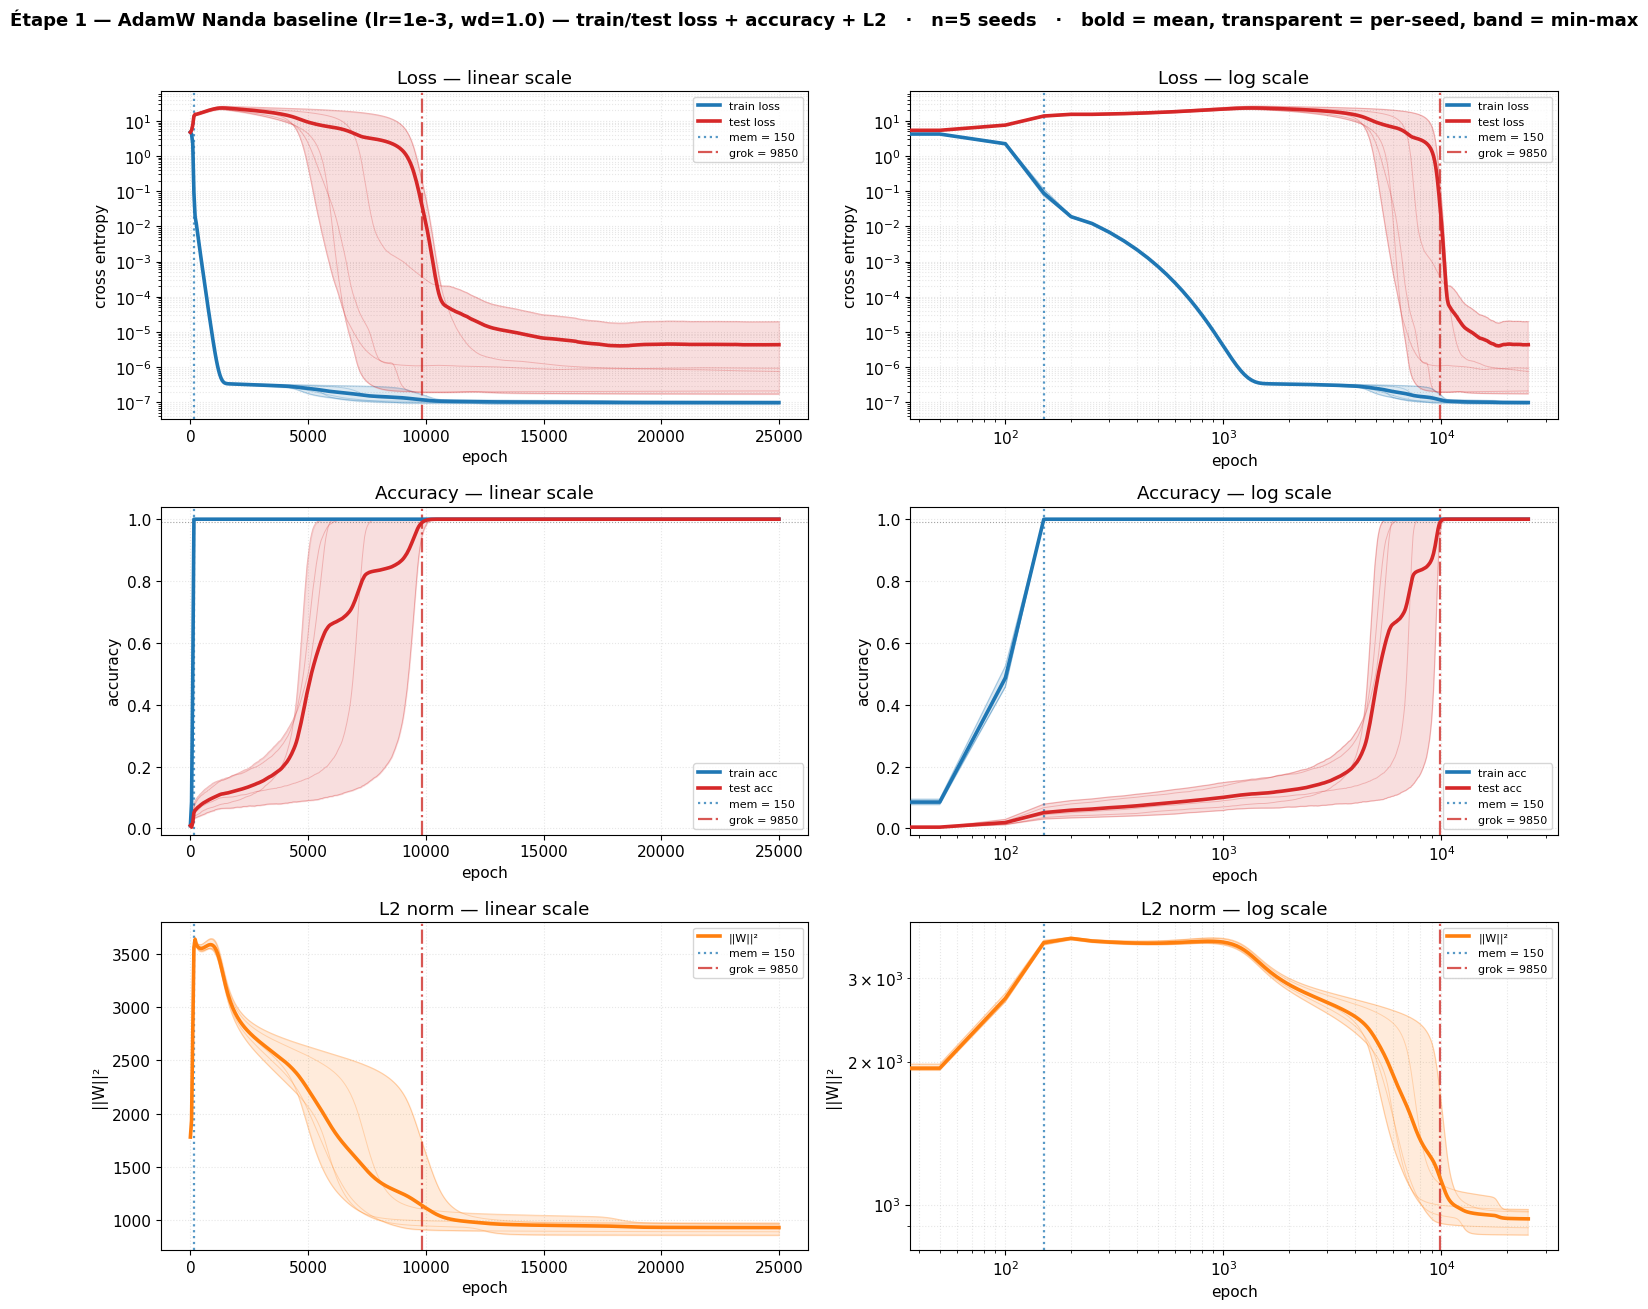


═══ AdamW Fast (lr=1e-2, wd=1.0) ═══
  mem=100.0   grok=550.0   (circuit non calculé : pas de Fourier en Étape 1)
  converged seeds (final_test_acc >= 0.99) : [0, 1, 2, 3, 4]


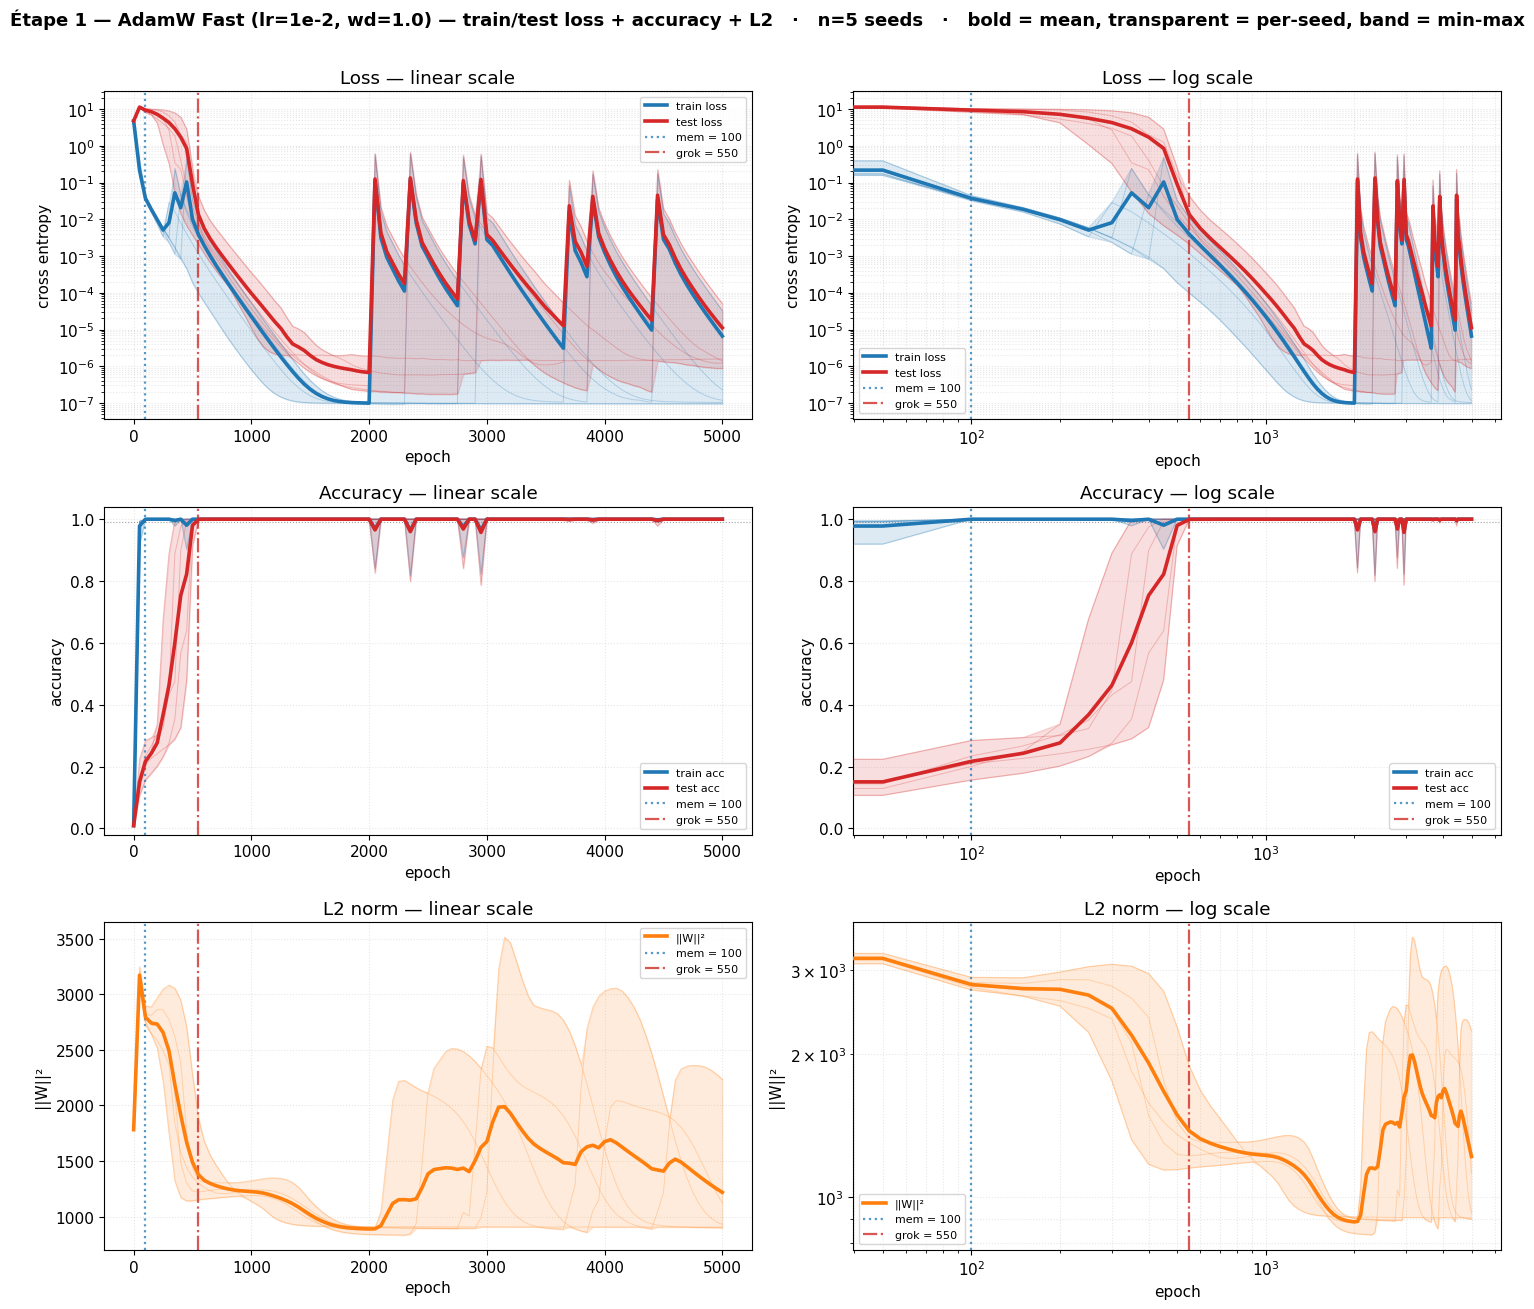

In [40]:
for name, cfg in OPTIMS.items():
    runs, _ = load_seeds(cfg['phaseA_dir'], SEEDS)
    cfg['runs_1']    = runs
    cfg['markers_1'] = compute_grokking_markers(runs)
    cfg['converged'] = [r['seed'] for r in runs if r['history']['test_acc'][-1] >= CONVERGED_THRESH]

    m = cfg['markers_1']
    print(f'\n═══ {cfg["label"]} ═══')
    print(f'  mem={m["mem"]}   grok={m["grok"]}   (circuit non calculé : pas de Fourier en Étape 1)')
    print(f'  converged seeds (final_test_acc >= {CONVERGED_THRESH}) : {cfg["converged"]}')

    plot_curves_band(
        runs, title=f'Étape 1 — {cfg["label"]} — train/test loss + accuracy + L2',
        markers=m,   # mem + grok seulement (circuit=None ignoré)
        save_path=FIG_DIR / f'step1_{name}_curves.png',
    )

## 1.3 — Identification des fréquences caractéristiques

Charge `model.pt` final de chaque seed convergé, projette W_E et W_U sur la base Fourier réelle, extrait les top-5 freqs.


═══ AdamW Nanda baseline (lr=1e-3, wd=1.0) — identification key_freqs ═══


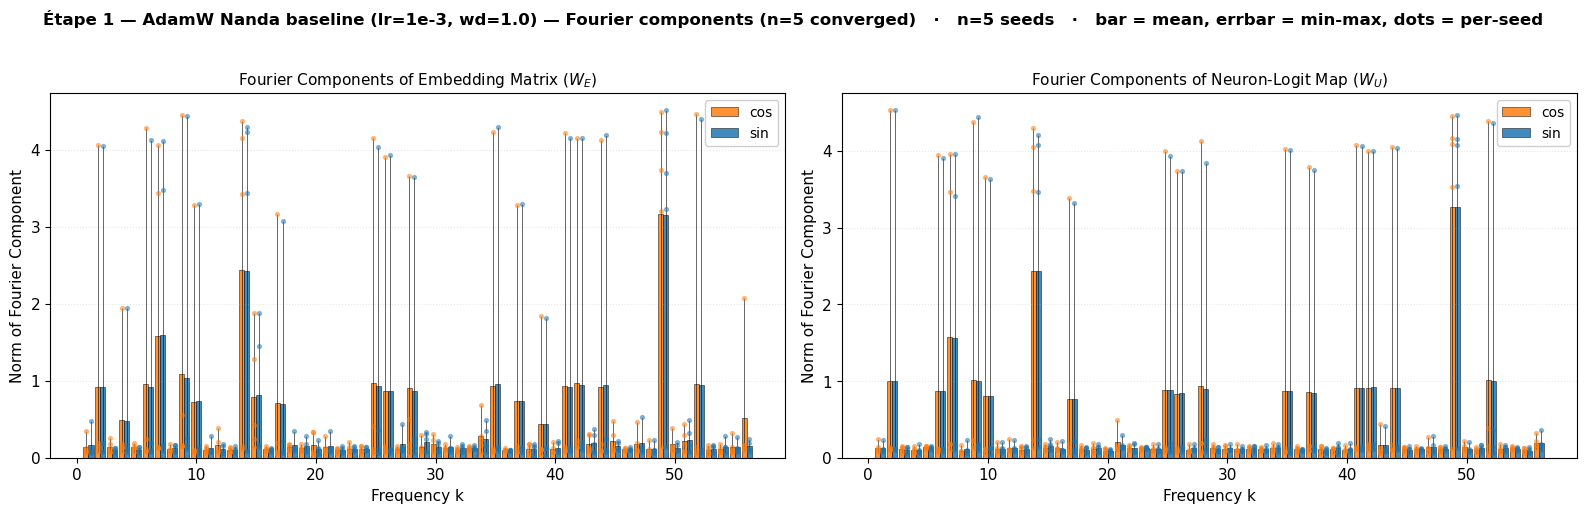

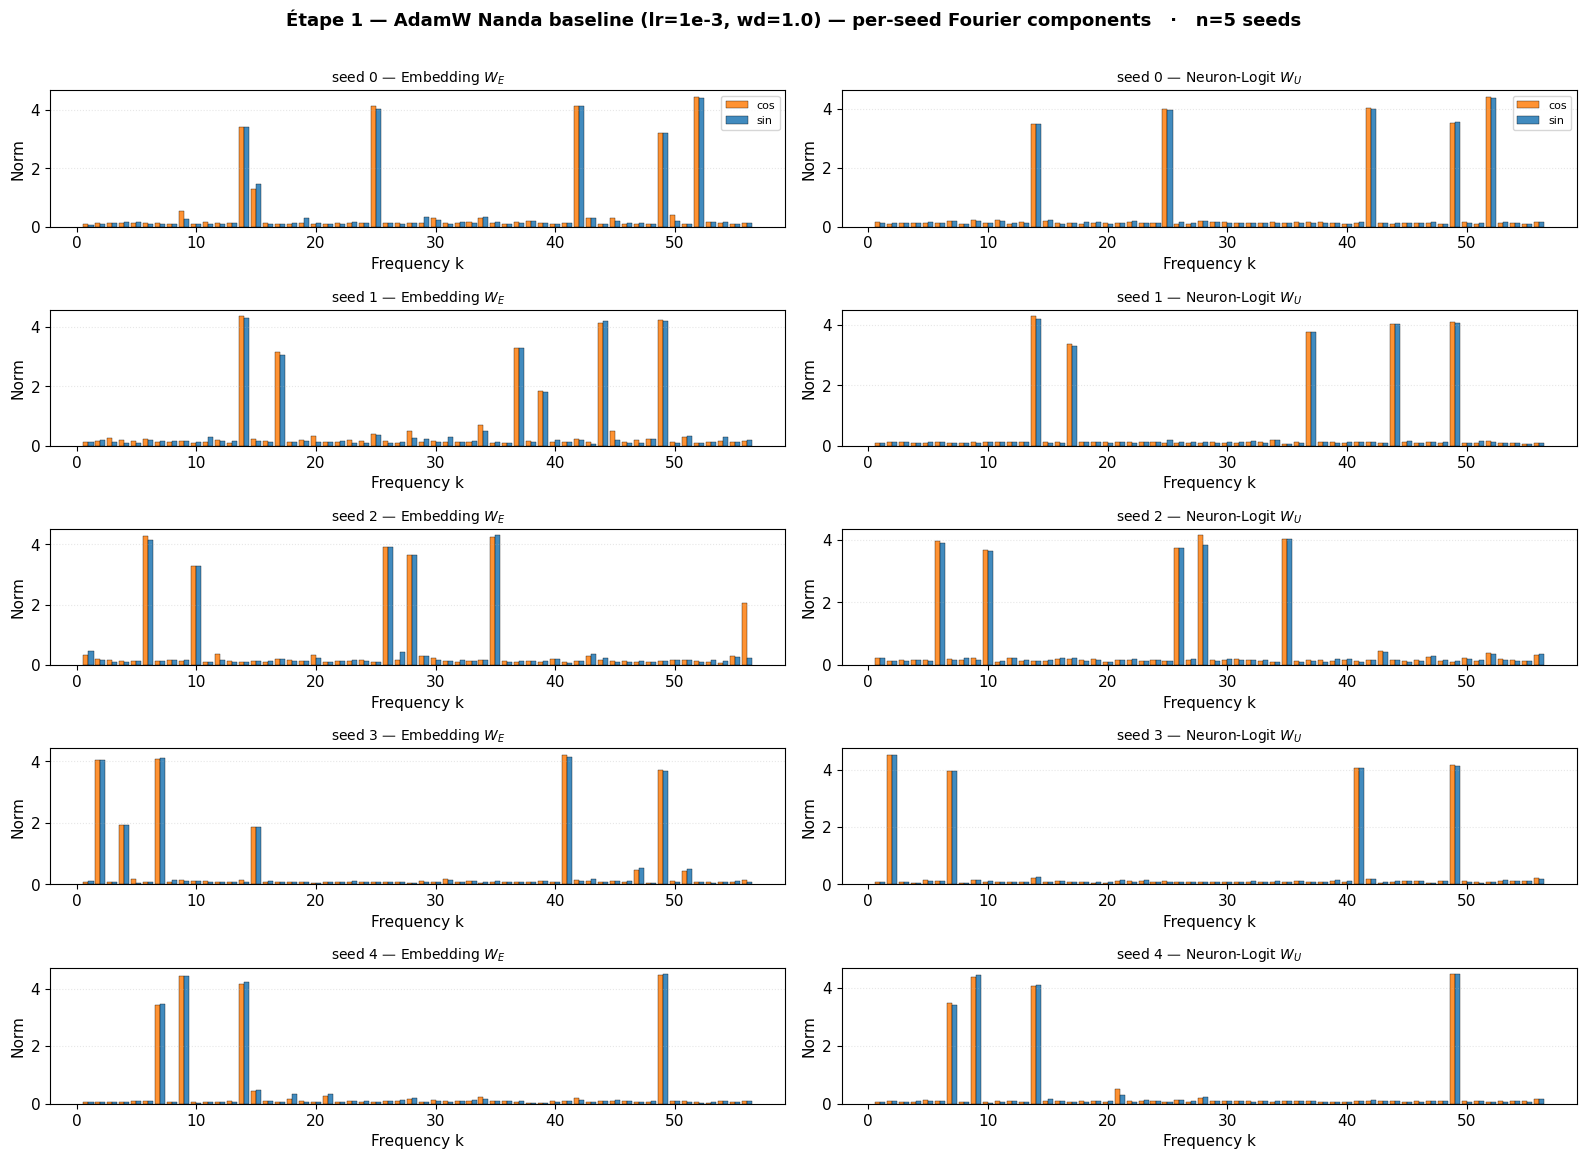


  Top-5 freqs PAR SEED (utilisés en Étape 2 pour le restricted loss) :
    seed 0 : [14, 25, 42, 49, 52]
    seed 1 : [14, 17, 37, 44, 49]
    seed 2 : [6, 10, 26, 28, 35]
    seed 3 : [2, 4, 7, 41, 49]
    seed 4 : [7, 9, 14, 21, 49]

  Cross-seed consensus : []   majority : [14, 49]

═══ AdamW Fast (lr=1e-2, wd=1.0) — identification key_freqs ═══


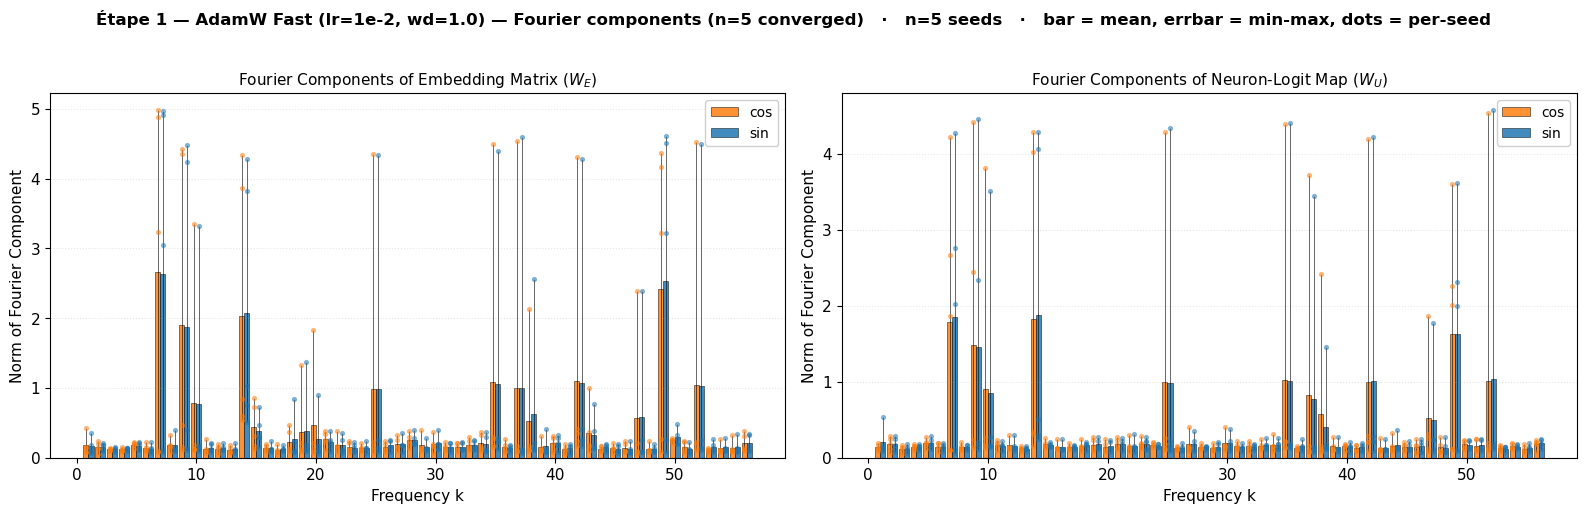

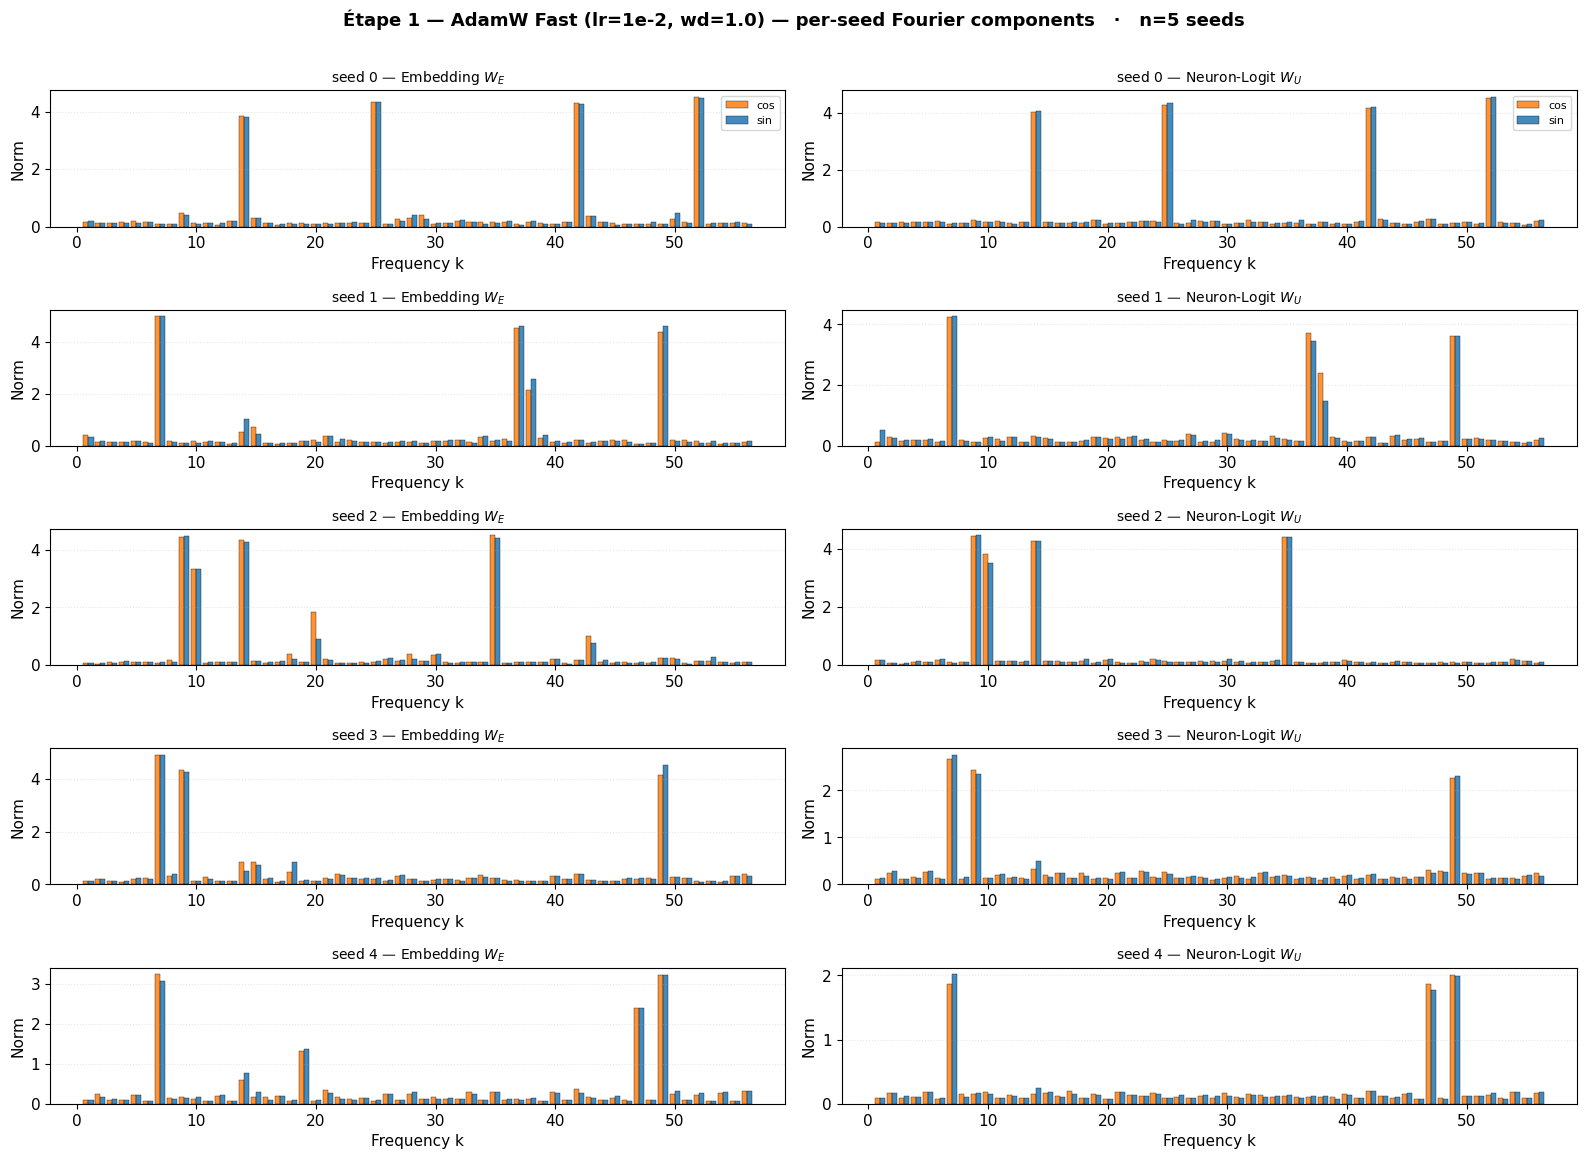


  Top-5 freqs PAR SEED (utilisés en Étape 2 pour le restricted loss) :
    seed 0 : [9, 14, 25, 42, 52]
    seed 1 : [7, 14, 37, 38, 49]
    seed 2 : [9, 10, 14, 20, 35]
    seed 3 : [7, 9, 14, 15, 49]
    seed 4 : [7, 14, 19, 47, 49]

  Cross-seed consensus : [14]   majority : [7, 9, 14, 49]


In [41]:
for name, cfg in OPTIMS.items():
    print(f'\n═══ {cfg["label"]} — identification key_freqs ═══')
    converged = cfg['converged']
    if len(converged) < 3:
        print(f'  ⚠ moins de 3 seeds convergés ({converged}) — augmenter num_epochs')
        continue

    # Bar chart agrégé multi-seeds (visualisation cross-seed)
    per_seed = plot_fourier_components(
        save_root=cfg['phaseA_dir'], seeds=converged, config=cfg['config'],
        title=f'Étape 1 — {cfg["label"]} — Fourier components (n={len(converged)} converged)',
        save_path=FIG_DIR / f'step1_{name}_fourier_components.png',
    )
    # Bar chart par seed (variabilité)
    plot_fourier_components_per_seed(
        save_root=cfg['phaseA_dir'], seeds=converged, config=cfg['config'],
        title=f'Étape 1 — {cfg["label"]} — per-seed Fourier components',
        save_path=FIG_DIR / f'step1_{name}_per_seed.png',
    )

    # Identification top-5 par seed (utilisé en Étape 2 pour le restricted/excluded loss)
    kf5 = identify_key_freqs(per_seed, k=5)
    cfg['per_seed_freqs'] = kf5['per_seed']    # ← {seed: top-5 freqs} pour Étape 2

    print(f'\n  Top-5 freqs PAR SEED (utilisés en Étape 2 pour le restricted loss) :')
    for s, freqs in kf5['per_seed'].items():
        print(f'    seed {s} : {freqs}')

    # Agrégation cross-seed (pour comparaison config-à-config seulement, pas pour Étape 2)
    cfg['key_freqs_consensus'] = kf5['consensus']
    cfg['key_freqs_majority']  = kf5['majority']
    print(f'\n  Cross-seed consensus : {kf5["consensus"]}   majority : {kf5["majority"]}')

## 1.4 — Comparaison key_freqs Nanda vs Fast

In [42]:
# Comparaison inter-config via majority freqs (les freqs partagées par >=3 seeds)
kf_nanda = set(OPTIMS['nanda'].get('key_freqs_majority', []))
kf_fast  = set(OPTIMS['fast'].get('key_freqs_majority', []))
shared   = kf_nanda & kf_fast
print('═══ Comparaison cross-config (via majority freqs) ═══')
print(f'  Nanda  : {sorted(kf_nanda)}')
print(f'  Fast   : {sorted(kf_fast)}')
print(f'  shared : {sorted(shared)}')
print(f'  only Nanda : {sorted(kf_nanda - kf_fast)}')
print(f'  only Fast  : {sorted(kf_fast - kf_nanda)}')
if kf_nanda and kf_fast:
    jaccard = len(shared) / len(kf_nanda | kf_fast)
    verdict = ('MÊME circuit' if jaccard > 0.8 else 'circuits partiellement partagés' if jaccard > 0.3 else 'circuits DIFFÉRENTS')
    print(f'\n  Jaccard = {jaccard:.2f}  →  {verdict}')

print(f'\nNote : en Étape 2, chaque seed utilisera SON propre top-5 (per_seed_freqs), pas les freqs agrégées ci-dessus.')

═══ Comparaison cross-config (via majority freqs) ═══
  Nanda  : [14, 49]
  Fast   : [7, 9, 14, 49]
  shared : [14, 49]
  only Nanda : []
  only Fast  : [7, 9]

  Jaccard = 0.50  →  circuits partiellement partagés

Note : en Étape 2, chaque seed utilisera SON propre top-5 (per_seed_freqs), pas les freqs agrégées ci-dessus.


# ════════════════════════════════════════════════════
# ÉTAPE 2 — Re-train avec key_freqs fixés + Fourier
# ════════════════════════════════════════════════════

Chaque snapshot Fourier utilisera **exactement les freqs identifiées en Étape 1** → restricted/excluded loss propres tout au long du training.

## 2.1 — Re-train avec `fixed_key_freqs`

In [ ]:
from pipeline import Trainer

for name, cfg in OPTIMS.items():
    per_seed_freqs = cfg.get('per_seed_freqs', {})
    if not per_seed_freqs:
        print(f'\n⚠ {name} : pas de per_seed_freqs identifiés en Étape 1 — skip')
        continue

    print(f'\n═══ Étape 2 — {name} — per-seed key_freqs ═══')
    for s, kf in per_seed_freqs.items():
        print(f'  seed {s} : key_freqs = {kf}')

    # Boucle manuelle : chaque seed avec SON propre fixed_key_freqs
    for s in sorted(per_seed_freqs.keys()):
        seed_dir = cfg['phaseB_dir'] / f'seed{s}'
        if (seed_dir / 'history.json').exists():
            print(f'\n  ✓ seed {s} already done — skip')
            continue
        seed_kf = per_seed_freqs[s]
        print(f'\n  → training seed {s} with key_freqs = {seed_kf}')
        trainer = Trainer(
            cfg['config'], cfg['specs'],
            seed=s, label=f'{name}_step2_seed{s}',
            eval_every=EVAL_EVERY,
            fourier_every=cfg['fourier_every'],
            fixed_key_freqs=seed_kf,
            warmup_steps=WARMUP_STEPS,
            verbose_every=2_500 if name=='nanda' else 500,
        )
        trainer.fit()
        trainer.save_run(str(seed_dir))
        print(f'  ✓ seed {s} saved to {seed_dir}')


═══ Étape 2 — nanda — per-seed key_freqs ═══
  seed 0 : key_freqs = [14, 25, 42, 49, 52]
  seed 1 : key_freqs = [14, 17, 37, 44, 49]
  seed 2 : key_freqs = [6, 10, 26, 28, 35]
  seed 3 : key_freqs = [2, 4, 7, 41, 49]
  seed 4 : key_freqs = [7, 9, 14, 21, 49]

  → training seed 0 with key_freqs = [14, 25, 42, 49, 52]
  [nanda_step2_seed0 seed=0] epoch     0 | train acc 0.009 | test acc 0.009
  [nanda_step2_seed0 seed=0] epoch  2500 | train acc 1.000 | test acc 0.073
  [nanda_step2_seed0 seed=0] epoch  5000 | train acc 1.000 | test acc 0.090
  [nanda_step2_seed0 seed=0] epoch  7500 | train acc 1.000 | test acc 0.146
  [nanda_step2_seed0 seed=0] epoch 10000 | train acc 1.000 | test acc 0.980
  [nanda_step2_seed0 seed=0] epoch 12500 | train acc 1.000 | test acc 1.000
  [nanda_step2_seed0 seed=0] epoch 15000 | train acc 1.000 | test acc 1.000
  [nanda_step2_seed0 seed=0] epoch 17500 | train acc 1.000 | test acc 1.000
  [nanda_step2_seed0 seed=0] epoch 20000 | train acc 1.000 | test acc 1.0

## 2.2 — Reload + plots Fourier (restricted/excluded, freq masses, sparsity)

In [ ]:
for name, cfg in OPTIMS.items():
    if not cfg.get('per_seed_freqs'): continue
    # Reload uniquement les seeds qu'on a re-trainé en Étape 2 (= seeds convergés en Étape 1)
    seeds_to_reload = sorted(cfg['per_seed_freqs'].keys())
    runs, _ = load_seeds(cfg['phaseB_dir'], seeds_to_reload)
    cfg['runs_2']    = runs
    cfg['markers_2'] = compute_grokking_markers(runs)

    print(f'\n═══ {cfg["label"]} — Étape 2 (n={len(runs)} seeds) ═══')
    m = cfg['markers_2']
    print(f'  mem={m["mem"]}   circuit={m["circuit"]}   grok={m["grok"]}')

    plot_fourier_losses_band(
        runs, title=f'Étape 2 — {cfg["label"]} — Fourier loss (per-seed key_freqs)',
        markers=m,
        save_path=FIG_DIR / f'step2_{name}_fourier_loss.png',
    )
    plot_freq_mass_heatmap(
        runs, title=f'Étape 2 — {cfg["label"]} — frequency masses',
        markers=m,
        save_path=FIG_DIR / f'step2_{name}_freq_masses.png',
    )
    plot_sparsity(
        runs, title=f'Étape 2 — {cfg["label"]} — sparsity',
        markers=m,
        save_path=FIG_DIR / f'step2_{name}_sparsity.png',
    )

## 2.3 — Summary

In [ ]:
print('═══ SUMMARY ═══\n')
print(f'{"config":12} {"key_freqs":30} {"mem (1)":>9} {"grok (1)":>10} {"circuit (2)":>12} {"grok (2)":>10}')
print('-' * 95)
for name, cfg in OPTIMS.items():
    kf  = cfg.get('key_freqs', [])
    m1  = cfg.get('markers_1', {})
    m2  = cfg.get('markers_2', {})
    print(f'{name:12} {str(kf):30} '
          f'{str(m1.get("mem")):>9} {str(m1.get("grok")):>10} '
          f'{str(m2.get("circuit")):>12} {str(m2.get("grok")):>10}')
print(f'\nFigures saved to : {FIG_DIR}/')